In [14]:
import os
import numpy as np
import h5py
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

In [15]:
# ── 通道定義 & 五腦區分組 ──
CH_NAMES = [
    'Fp1','Fz','F3','F7','FT9','FC5','FC1',   # 0-6
    'C3','T7','TP9','CP5','CP1','Pz','P3','P7', # 7-14
    'O1','Oz','O2',                              # 15-17
    'P4','P8','TP10','CP6','CP2','Cz','C4','T8', # 18-25
    'FT10','FC6','FC2','F4','F8','Fp2'           # 26-31
]

REGIONS = {
    'Frontal':   [0, 31, 2, 29, 3, 30, 1],               # Fp1,Fp2,F3,F4,F7,F8,Fz (7ch)
    'Central':   [7, 24, 23, 6, 28, 5, 27],               # C3,C4,Cz,FC1,FC2,FC5,FC6 (7ch)
    'Parietal':  [13, 18, 14, 19, 12, 11, 22, 10, 21],    # P3,P4,P7,P8,Pz,CP1,CP2,CP5,CP6 (9ch)
    'Temporal':  [8, 25, 4, 26, 9, 20],                   # T7,T8,FT9,FT10,TP9,TP10 (6ch)
    'Occipital': [15, 17, 16],                             # O1,O2,Oz (3ch)
}

BAND_NAMES = ['delta', 'theta', 'alpha', 'beta', 'gamma']
CLASS_NAMES = ['amateur', 'master', 'prof']

for name, chs in REGIONS.items():
    ch_names = [CH_NAMES[i] for i in chs]
    print(f'{name} ({len(chs)}ch): {ch_names}')

Frontal (7ch): ['Fp1', 'Fp2', 'F3', 'F4', 'F7', 'F8', 'Fz']
Central (7ch): ['C3', 'C4', 'Cz', 'FC1', 'FC2', 'FC5', 'FC6']
Parietal (9ch): ['P3', 'P4', 'P7', 'P8', 'Pz', 'CP1', 'CP2', 'CP5', 'CP6']
Temporal (6ch): ['T7', 'T8', 'FT9', 'FT10', 'TP9', 'TP10']
Occipital (3ch): ['O1', 'O2', 'Oz']


In [16]:
# ── PLV 資料載入 ──

def get_subject_id(filename):
    return filename.split('_ses-')[0]

def scan_plv_folder(folder_path):
    result = {}
    for fname in sorted(os.listdir(folder_path)):
        if fname.endswith('.mat'):
            result[get_subject_id(fname)] = os.path.join(folder_path, fname)
    return result

def load_plv(filepath):
    """載入 PLV，回傳 (5bands, 200time, 32, 32)"""
    with h5py.File(filepath, 'r') as f:
        rm = f['result_mats']
        bands_data = []
        for band in BAND_NAMES:
            bands_data.append(np.array(rm[band]))  # (200, 32, 32)
    return np.array(bands_data)  # (5, 200, 32, 32)

def load_plv_group(ss01_map, ss02_map, ss03_map, complete_subs):
    X1, X2, X3 = [], [], []
    for sub_id in complete_subs:
        X1.append(load_plv(ss01_map[sub_id]))
        X2.append(load_plv(ss02_map[sub_id]))
        X3.append(load_plv(ss03_map[sub_id]))
    return np.array(X1), np.array(X2), np.array(X3)

BASE_AMATEUR = r'D:\Tseng\圍棋\amateur\PLV_Results_2026'
BASE_MASTER  = r'D:\Tseng\圍棋\master\PLV_Results_2026'
BASE_PROF    = r'D:\Tseng\圍棋\prof\PLV_Results_2026'

PATHS = {
    'amateur': {s: os.path.join(BASE_AMATEUR, s) for s in ['ss01','ss02','ss03']},
    'master':  {s: os.path.join(BASE_MASTER,  s) for s in ['ss01','ss02','ss03']},
    'prof':    {s: os.path.join(BASE_PROF,    s) for s in ['ss01','ss02','ss03']},
}

maps = {}
complete = {}
for group in ['amateur', 'master', 'prof']:
    m1 = scan_plv_folder(PATHS[group]['ss01'])
    m2 = scan_plv_folder(PATHS[group]['ss02'])
    m3 = scan_plv_folder(PATHS[group]['ss03'])
    maps[group] = (m1, m2, m3)
    complete[group] = sorted(set(m1) & set(m2) & set(m3))
    print(f'[{group}] 完整 subject：{len(complete[group])} 人')

print('\n載入 PLV 資料...')
X_a1, X_a2, X_a3 = load_plv_group(*maps['amateur'], complete['amateur'])
X_m1, X_m2, X_m3 = load_plv_group(*maps['master'],  complete['master'])
X_p1, X_p2, X_p3 = load_plv_group(*maps['prof'],    complete['prof'])
print(f'完成  shape: {X_a1.shape},{X_m1.shape},{X_p1.shape}, (n_sub, 5bands, 200time, 32ch, 32ch)')


[amateur] 完整 subject：28 人
[master] 完整 subject：20 人
[prof] 完整 subject：8 人

載入 PLV 資料...
完成  shape: (28, 5, 200, 32, 32),(20, 5, 200, 32, 32),(8, 5, 200, 32, 32), (n_sub, 5bands, 200time, 32ch, 32ch)


In [17]:
# ── PLV 特徵提取 ──
# 取時間平均 → 上三角 (去除對角線) → flatten
# 全 32ch: 每 band 有 32*31/2 = 496 個連結，5 bands → 2480 dims

triu_idx = np.triu_indices(32, k=1)  # 上三角 index (不含對角線)

def extract_plv_features(X, ch_idx=None):
    """
    X: (n_sub, 5bands, 200time, 32ch, 32ch)
    ch_idx: 選擇的通道 index，None 表示全 32ch
    回傳: (n_sub, n_features)
    """
    X_mean = X.mean(axis=2)  # (n_sub, 5, 32, 32) 時間平均

    if ch_idx is not None:
        X_mean = X_mean[:, :, np.ix_(ch_idx, ch_idx)[0], np.ix_(ch_idx, ch_idx)[1]]
        n_ch = len(ch_idx)
        tri = np.triu_indices(n_ch, k=1)
    else:
        n_ch = 32
        tri = triu_idx

    feats = []
    for b in range(5):
        feats.append(X_mean[:, b, tri[0], tri[1]])  # (n_sub, n_pairs)
    return np.hstack(feats)  # (n_sub, n_pairs * 5)

n_a = len(complete['amateur'])
n_m = len(complete['master'])
n_p = len(complete['prof'])
n_total = n_a + n_m + n_p

raw = {
    'amateur': [X_a1, X_a2, X_a3],
    'master':  [X_m1, X_m2, X_m3],
    'prof':    [X_p1, X_p2, X_p3],
}

# 排列方式與 svm_band_energy.ipynb 一致: group-then-session
plv_all = []
for g in CLASS_NAMES:
    for Xr in raw[g]:
        plv_all.append(Xr)
X_plv = np.vstack(plv_all)  # (168, 5, 200, 32, 32)

y_all = np.concatenate([np.zeros(n_a * 3), np.ones(n_m * 3), np.full(n_p * 3, 2)])
subject_ids = complete['amateur'] + complete['master'] + complete['prof']
subject_split = np.concatenate([
    np.repeat(complete['amateur'], 3),
    np.repeat(complete['master'], 3),
    np.repeat(complete['prof'], 3),
])
subject_labels = {}
for g_idx, g in enumerate(CLASS_NAMES):
    for s in complete[g]:
        subject_labels[s] = g_idx

print(f'X_plv shape: {X_plv.shape}')
print(f'Total subjects: {n_total}  (Amateur: {n_a}, Master: {n_m}, Prof: {n_p})')
print(f'上三角連結數 (全 32ch): {len(triu_idx[0])} pairs × 5 bands = {len(triu_idx[0])*5} dims')

X_plv shape: (168, 5, 200, 32, 32)
Total subjects: 56  (Amateur: 28, Master: 20, Prof: 8)
上三角連結數 (全 32ch): 496 pairs × 5 bands = 2480 dims


In [18]:
# ── LOSO 函式 (PLV 版，PCA 95% explained variance) ──

def run_loso_plv(X_plv, ch_idx, y_all, subject_split, subject_ids, subject_labels,
                 pca_variance=0.95):
    """
    X_plv: (168, 5, 200, 32, 32)
    ch_idx: 通道 index list，None 表示全 32ch
    """
    X_feat = extract_plv_features(X_plv, ch_idx)
    dims = X_feat.shape[1]

    all_preds, all_true = [], []
    per_sub = []
    pca_dims_list = []

    for test_subject in subject_ids:
        test_mask  = subject_split == test_subject
        train_mask = ~test_mask

        X_tr, y_tr = X_feat[train_mask], y_all[train_mask].astype(int)
        X_te, y_te = X_feat[test_mask],  y_all[test_mask].astype(int)

        scaler = StandardScaler()
        X_tr = scaler.fit_transform(X_tr)
        X_te = scaler.transform(X_te)

        pca = PCA(n_components=pca_variance)
        X_tr = pca.fit_transform(X_tr)
        X_te = pca.transform(X_te)
        pca_dims_list.append(pca.n_components_)

        clf = SVC(kernel='rbf', C=10, gamma='scale',
                  class_weight='balanced', random_state=42)
        clf.fit(X_tr, y_tr)
        preds = clf.predict(X_te)

        acc = accuracy_score(y_te, preds)
        f1  = f1_score(y_te, preds, average='macro', zero_division=0)
        per_sub.append({'acc': acc, 'f1': f1, 'subject': test_subject,
                        'true': subject_labels[test_subject]})
        all_preds.extend(preds)
        all_true.extend(y_te)

    all_preds = np.array(all_preds)
    all_true  = np.array(all_true)
    mean_acc = np.mean([r['acc'] for r in per_sub])
    mean_f1  = f1_score(all_true, all_preds, average='macro', zero_division=0)
    pca_n = int(np.median(pca_dims_list))
    return mean_acc, mean_f1, per_sub, all_preds, all_true, pca_n

In [19]:
# ── 五腦區 + 全 32ch LOSO ──

region_results = {}

# 各腦區
for region_name, ch_idx in REGIONS.items():
    n_ch = len(ch_idx)
    n_pairs = n_ch * (n_ch - 1) // 2
    dims = n_pairs * 5

    acc, f1, per_sub, preds, true, pca_n = run_loso_plv(
        X_plv, ch_idx, y_all, subject_split, subject_ids, subject_labels
    )
    region_results[region_name] = {
        'acc': acc, 'f1': f1, 'dims': dims, 'pca': pca_n,
        'preds': preds, 'true': true, 'per_sub': per_sub,
        'ch_idx': ch_idx,
    }
    print(f'[{region_name:<10s}] {n_ch:2d}ch  {n_pairs:3d} pairs × 5bands = {dims:4d} dims  '
          f'PCA(95%)→{pca_n:2d}  Acc={acc:.3f}  F1={f1:.3f}')

# 全 32ch
n_pairs_all = 32 * 31 // 2
dims_all = n_pairs_all * 5

acc_all, f1_all, per_sub_all, preds_all, true_all, pca_n_all = run_loso_plv(
    X_plv, None, y_all, subject_split, subject_ids, subject_labels
)
print(f'[{"ALL_32ch":<10s}] 32ch  {n_pairs_all:3d} pairs × 5bands = {dims_all:4d} dims  '
      f'PCA(95%)→{pca_n_all:2d}  Acc={acc_all:.3f}  F1={f1_all:.3f}')

[Frontal   ]  7ch   21 pairs × 5bands =  105 dims  PCA(95%)→16  Acc=0.536  F1=0.491
[Central   ]  7ch   21 pairs × 5bands =  105 dims  PCA(95%)→19  Acc=0.583  F1=0.526
[Parietal  ]  9ch   36 pairs × 5bands =  180 dims  PCA(95%)→21  Acc=0.738  F1=0.736
[Temporal  ]  6ch   15 pairs × 5bands =   75 dims  PCA(95%)→10  Acc=0.506  F1=0.468
[Occipital ]  3ch    3 pairs × 5bands =   15 dims  PCA(95%)→ 4  Acc=0.446  F1=0.444
[ALL_32ch  ] 32ch  496 pairs × 5bands = 2480 dims  PCA(95%)→57  Acc=0.726  F1=0.728


In [20]:
# ── Save region results for cross-notebook comparison ──
import json
_out = {rn: {'acc': float(r['acc']), 'f1': float(r['f1'])}
        for rn, r in region_results.items()}
_out_path = r'D:\Tseng\game_eeg\SVM_PLV\svm_plv_results.json'
with open(_out_path, 'w', encoding='utf-8') as _f:
    json.dump(_out, _f, indent=2)
print(f'Saved → {_out_path}')
print(_out)

Saved → D:\Tseng\game_eeg\SVM_PLV\svm_plv_results.json
{'Frontal': {'acc': 0.5357142857142857, 'f1': 0.49063431247339295}, 'Central': {'acc': 0.5833333333333333, 'f1': 0.5264808684355006}, 'Parietal': {'acc': 0.738095238095238, 'f1': 0.7362921981579899}, 'Temporal': {'acc': 0.5059523809523809, 'f1': 0.4683263711885208}, 'Occipital': {'acc': 0.44642857142857145, 'f1': 0.4444444444444444}}


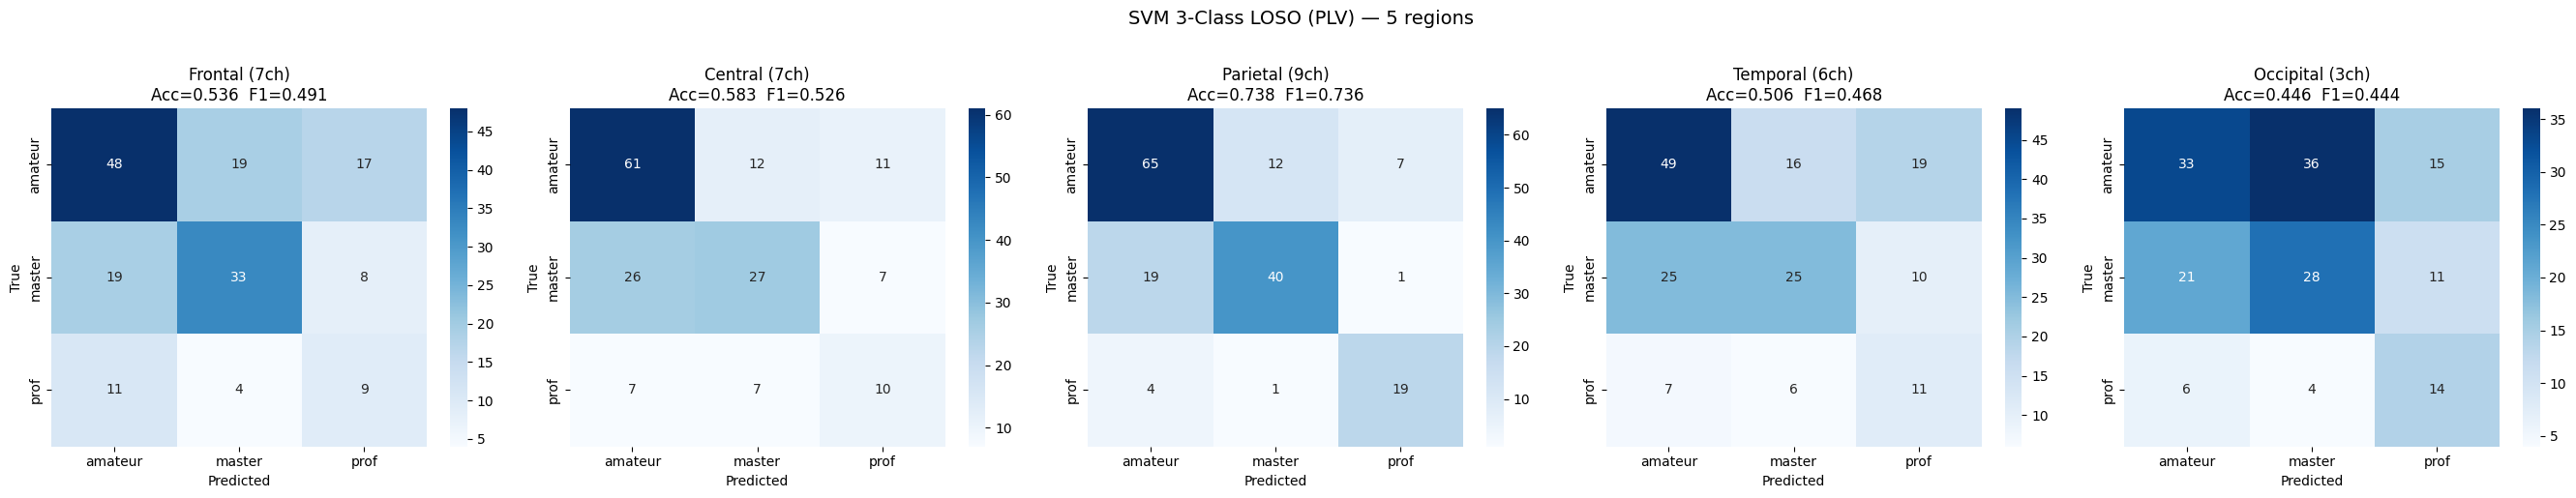

In [21]:
# ── 混淆矩陣 ──

fig, axes = plt.subplots(1, 5, figsize=(27, 5))

for ax, (region_name, r) in zip(axes, region_results.items()):
    cm = confusion_matrix(r['true'], r['preds'], labels=[0, 1, 2])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=ax)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')
    n_ch = len(r['ch_idx'])
    ax.set_title(f'{region_name} ({n_ch}ch)\nAcc={r["acc"]:.3f}  F1={r["f1"]:.3f}')

plt.suptitle('SVM 3-Class LOSO (PLV) — 5 regions', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(r'D:\Tseng\game_eeg\SVM_PLV\svm_plv_region5_confusion.png',
            dpi=150, bbox_inches='tight')
plt.show()

In [22]:
# ── 各腦區 Classification Report ──

for region_name, r in region_results.items():
    n_ch = len(r['ch_idx'])
    print(f'\n{"="*60}')
    print(f'{region_name} ({n_ch}ch)  Acc={r["acc"]:.3f}  F1={r["f1"]:.3f}')
    print(f'{"="*60}')
    print(classification_report(r['true'], r['preds'],
                                target_names=CLASS_NAMES, zero_division=0))


Frontal (7ch)  Acc=0.536  F1=0.491
              precision    recall  f1-score   support

     amateur       0.62      0.57      0.59        84
      master       0.59      0.55      0.57        60
        prof       0.26      0.38      0.31        24

    accuracy                           0.54       168
   macro avg       0.49      0.50      0.49       168
weighted avg       0.56      0.54      0.54       168


Central (7ch)  Acc=0.583  F1=0.526
              precision    recall  f1-score   support

     amateur       0.65      0.73      0.69        84
      master       0.59      0.45      0.51        60
        prof       0.36      0.42      0.38        24

    accuracy                           0.58       168
   macro avg       0.53      0.53      0.53       168
weighted avg       0.59      0.58      0.58       168


Parietal (9ch)  Acc=0.738  F1=0.736
              precision    recall  f1-score   support

     amateur       0.74      0.77      0.76        84
      master       0

In [23]:
# ── PLV Session 擾動實驗 準備 ──

SESSION_NAMES = ['ss01', 'ss02', 'ss03']

# 建立 per-session PLV 資料，subject 順序: amateur → master → prof
plv_by_session = [
    np.vstack([X_a1, X_m1, X_p1]),  # ss01: (56, 5, 200, 32, 32)
    np.vstack([X_a2, X_m2, X_p2]),  # ss02
    np.vstack([X_a3, X_m3, X_p3]),  # ss03
]
print(f'plv_by_session: 3 × {plv_by_session[0].shape}')

def build_Xplv_from_sessions(plv_sessions, n_a, n_m, n_p):
    """
    plv_sessions: list of 3 arrays, each (n_total, 5, 200, 32, 32)
        subject 順序: amateur (0:n_a), master (n_a:n_a+n_m), prof (n_a+n_m:)
    回傳: (168, 5, 200, 32, 32)，排列為 group-then-session
    """
    parts = []
    group_slices = [(0, n_a), (n_a, n_a + n_m), (n_a + n_m, n_a + n_m + n_p)]
    for g_start, g_end in group_slices:
        for ss_idx in range(3):
            parts.append(plv_sessions[ss_idx][g_start:g_end])
    return np.vstack(parts)

plv_by_session: 3 × (56, 5, 200, 32, 32)


In [24]:
# ── PLV Session 擾動實驗 (每個腦區 × 每個 session) ──

N_REPEATS = 30

# Baseline (從前面的 region_results 取)
plv_baseline = {}
for rn in REGIONS:
    plv_baseline[rn] = {'acc': region_results[rn]['acc'], 'f1': region_results[rn]['f1']}

perturb_results = {}

for region_name, ch_idx in REGIONS.items():
    perturb_results[region_name] = {}
    print(f'\n── {region_name} ({len(ch_idx)}ch) ──')

    for ss_idx in range(3):
        accs, f1s = [], []
        for seed in range(N_REPEATS):
            rng = np.random.RandomState(seed)
            perturbed = [s.copy() for s in plv_by_session]
            perm = rng.permutation(n_total)
            perturbed[ss_idx] = perturbed[ss_idx][perm]

            X_plv_perm = build_Xplv_from_sessions(perturbed, n_a, n_m, n_p)

            acc, f1, _, _, _, _ = run_loso_plv(
                X_plv_perm, ch_idx, y_all, subject_split, subject_ids, subject_labels
            )
            accs.append(acc)
            f1s.append(f1)

        perturb_results[region_name][ss_idx] = {'accs': accs, 'f1s': f1s}
        m_acc = np.mean(accs)
        drop  = plv_baseline[region_name]['acc'] - m_acc
        print(f'  Perturb {SESSION_NAMES[ss_idx]}:  '
              f'Acc={m_acc:.3f}±{np.std(accs):.3f}  (drop={drop:+.3f})')


── Frontal (7ch) ──
  Perturb ss01:  Acc=0.435±0.031  (drop=+0.101)
  Perturb ss02:  Acc=0.400±0.048  (drop=+0.135)
  Perturb ss03:  Acc=0.434±0.042  (drop=+0.101)

── Central (7ch) ──
  Perturb ss01:  Acc=0.489±0.034  (drop=+0.094)
  Perturb ss02:  Acc=0.408±0.044  (drop=+0.175)


KeyboardInterrupt: 

In [ ]:
# ── 擾動結果比較表 ──

region_names = list(REGIONS.keys())

print('=' * 80)
print('PLV Session 擾動實驗結果 — 五腦區')
print('=' * 80)
print(f'{"Region":<15s} {"Condition":<20s} {"Acc":>8s} {"Drop":>8s} {"F1":>8s} {"Drop":>8s}')
print('-' * 80)

for region_name in REGIONS:
    b = plv_baseline[region_name]
    print(f'{region_name:<15s} {"Baseline":<20s} {b["acc"]:8.3f} {"---":>8s} {b["f1"]:8.3f} {"---":>8s}')
    for ss_idx in range(3):
        r = perturb_results[region_name][ss_idx]
        m_acc = np.mean(r['accs'])
        m_f1  = np.mean(r['f1s'])
        d_acc = b['acc'] - m_acc
        d_f1  = b['f1']  - m_f1
        print(f'{"":15s} {"Perturb "+SESSION_NAMES[ss_idx]:<20s} {m_acc:8.3f} {d_acc:+8.3f} {m_f1:8.3f} {d_f1:+8.3f}')
    print()
print('=' * 80)

print('\n各腦區擾動影響最大的 session:')
for region_name in REGIONS:
    drops = [plv_baseline[region_name]['acc'] - np.mean(perturb_results[region_name][i]['accs'])
             for i in range(3)]
    best = np.argmax(drops)
    print(f'  {region_name:<15s} → {SESSION_NAMES[best]}  (Acc drop = {drops[best]:+.3f})')

PLV Session 擾動實驗結果 — 五腦區
Region          Condition                 Acc     Drop       F1     Drop
--------------------------------------------------------------------------------
Frontal         Baseline                0.536      ---    0.491      ---
                Perturb ss01            0.435   +0.101    0.396   +0.095
                Perturb ss02            0.400   +0.135    0.342   +0.149
                Perturb ss03            0.434   +0.101    0.380   +0.111

Central         Baseline                0.583      ---    0.526      ---
                Perturb ss01            0.489   +0.094    0.437   +0.090
                Perturb ss02            0.408   +0.175    0.354   +0.172
                Perturb ss03            0.435   +0.148    0.400   +0.127

Parietal        Baseline                0.738      ---    0.736      ---
                Perturb ss01            0.499   +0.239    0.482   +0.254
                Perturb ss02            0.489   +0.249    0.464   +0.272
                

C:\Users\user\AppData\Local\Temp\ipykernel_18612\4012346742.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(bp_data, labels=['ss01', 'ss02', 'ss03'], patch_artist=True)
C:\Users\user\AppData\Local\Temp\ipykernel_18612\4012346742.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(bp_data, labels=['ss01', 'ss02', 'ss03'], patch_artist=True)
C:\Users\user\AppData\Local\Temp\ipykernel_18612\4012346742.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(bp_data, labels=['ss01', 'ss02', 'ss03'], patch_artist=True)
C:\Users\user\AppData\Local\Temp\ipykernel_18612\401234

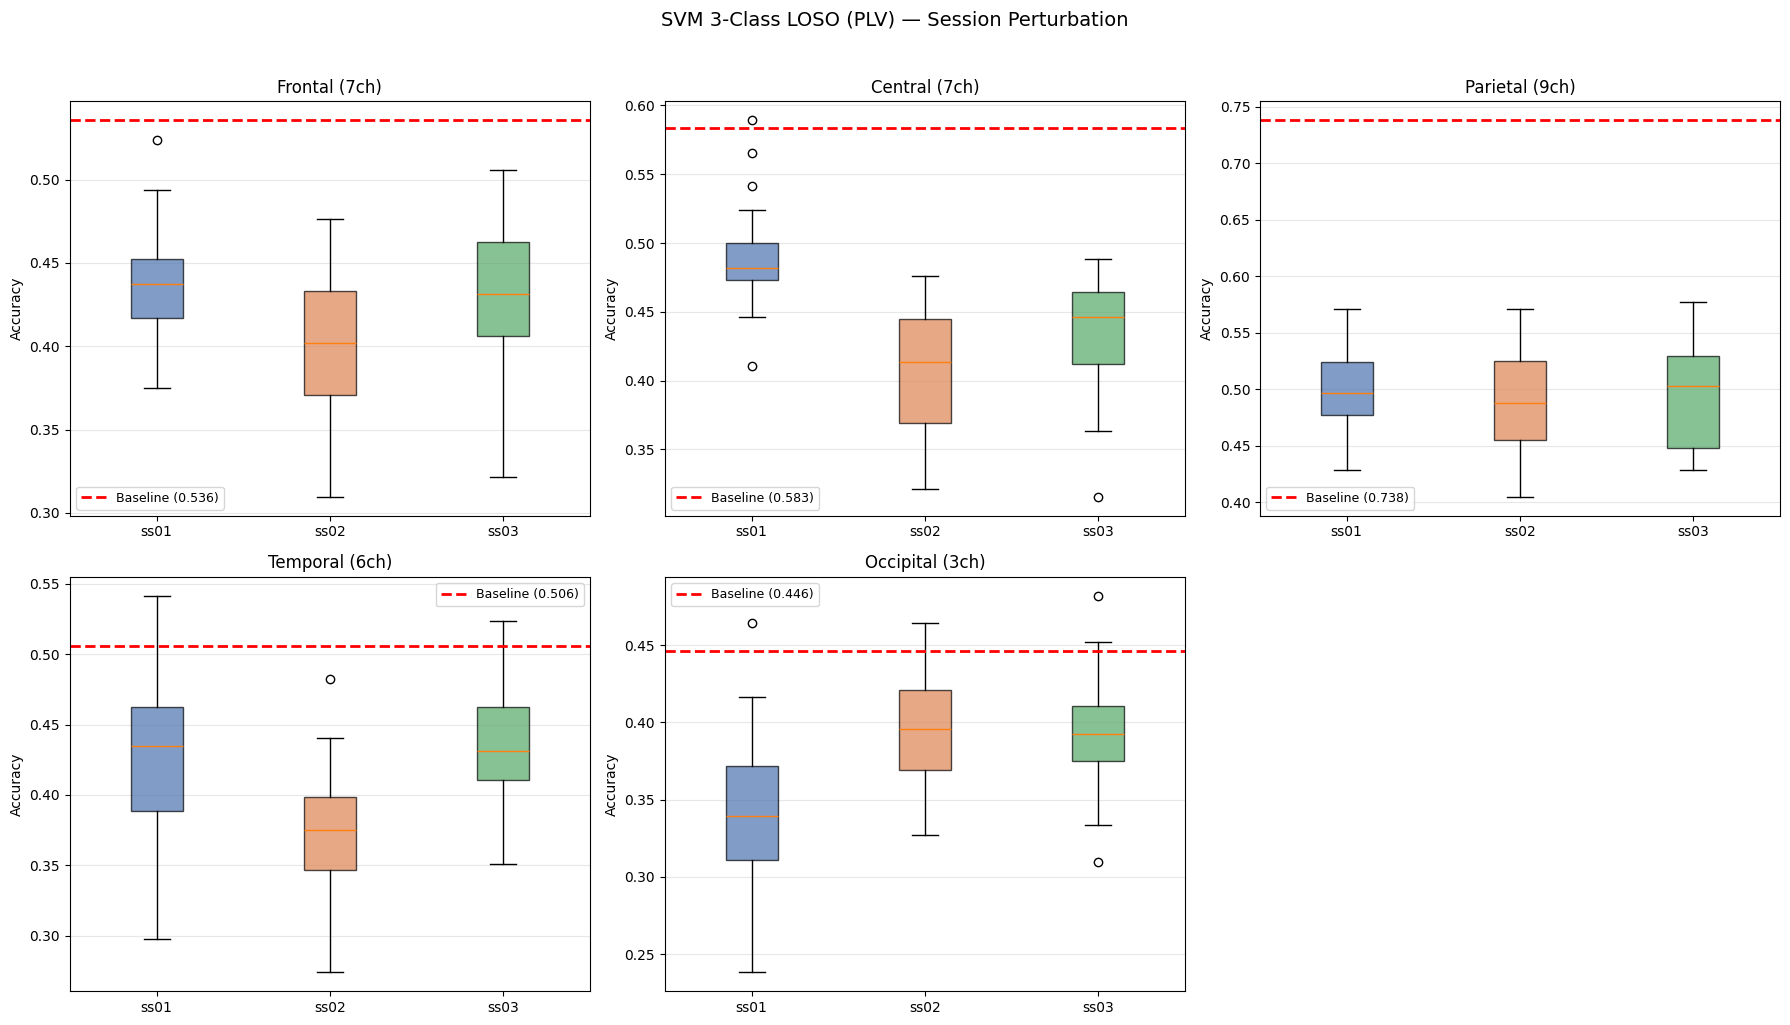

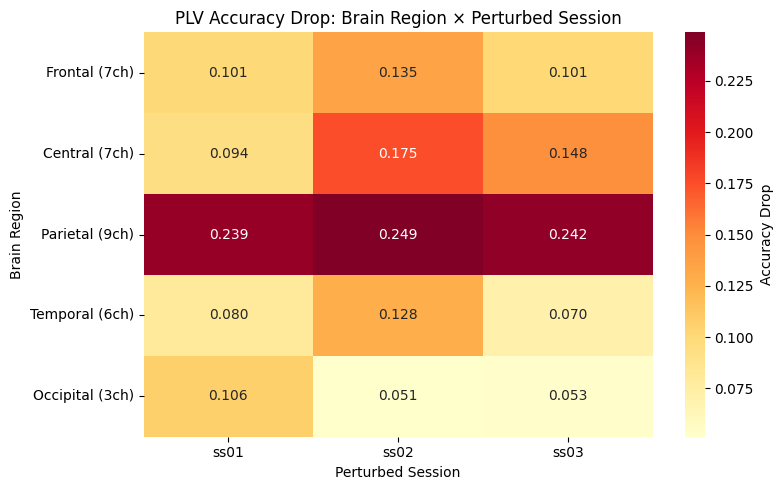

In [ ]:
# ── 擾動視覺化：Boxplot + Heatmap ──

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes_flat = axes.flatten()

# (上排) Boxplot: 5 腦區
for idx, (region_name, ch_idx) in enumerate(REGIONS.items()):
    ax = axes_flat[idx]
    n_ch = len(ch_idx)
    b_acc = plv_baseline[region_name]['acc']

    bp_data = [perturb_results[region_name][i]['accs'] for i in range(3)]
    bp = ax.boxplot(bp_data, labels=['ss01', 'ss02', 'ss03'], patch_artist=True)
    colors = ['#4C72B0', '#DD8452', '#55A868']
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    ax.axhline(y=b_acc, color='red', linestyle='--', linewidth=2,
               label=f'Baseline ({b_acc:.3f})')
    ax.set_ylabel('Accuracy')
    ax.set_title(f'{region_name} ({n_ch}ch)')
    ax.legend(fontsize=9)
    ax.grid(axis='y', alpha=0.3)

axes_flat[-1].set_visible(False)
plt.suptitle('SVM 3-Class LOSO (PLV) — Session Perturbation', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(r'D:\Tseng\game_eeg\SVM_PLV\svm_plv_perturbation_box.png',
            dpi=150, bbox_inches='tight')
plt.show()

# Accuracy Drop Heatmap
drop_matrix = np.zeros((len(region_names), 3))
for i, rn in enumerate(region_names):
    for ss_idx in range(3):
        drop_matrix[i, ss_idx] = plv_baseline[rn]['acc'] - np.mean(perturb_results[rn][ss_idx]['accs'])

fig, ax = plt.subplots(figsize=(8, 5))
sns.heatmap(drop_matrix, annot=True, fmt='.3f', cmap='YlOrRd',
            xticklabels=['ss01', 'ss02', 'ss03'],
            yticklabels=[f'{rn} ({len(REGIONS[rn])}ch)' for rn in region_names],
            ax=ax, cbar_kws={'label': 'Accuracy Drop'})
ax.set_xlabel('Perturbed Session')
ax.set_ylabel('Brain Region')
ax.set_title('PLV Accuracy Drop: Brain Region × Perturbed Session')
plt.tight_layout()
plt.savefig(r'D:\Tseng\game_eeg\SVM_PLV\svm_plv_perturbation_heatmap.png',
            dpi=150, bbox_inches='tight')
plt.show()

In [25]:
# ── Band Ablation @ Parietal (PLV only) — 設定 ──
from itertools import combinations

TARGET_REGION = 'Parietal'
TARGET_CH_IDX = REGIONS[TARGET_REGION]
print(f'Target: {TARGET_REGION} ({len(TARGET_CH_IDX)} ch)')

def extract_plv_features_bands(X, ch_idx, band_idx):
    """X: (N,5,200,32,32) -> mean over time -> select ch+band -> upper triangle"""
    X_mean = X.mean(axis=2)  # (N,5,32,32)
    X_mean = X_mean[:, band_idx][:, :, np.ix_(ch_idx, ch_idx)[0], np.ix_(ch_idx, ch_idx)[1]]
    n_ch = len(ch_idx)
    tri = np.triu_indices(n_ch, k=1)
    feats = [X_mean[:, b, tri[0], tri[1]] for b in range(len(band_idx))]
    return np.hstack(feats)

def evaluate_plv_band_subset(band_idx, ch_idx=TARGET_CH_IDX):
    X_feat = extract_plv_features_bands(X_plv, ch_idx, band_idx)
    all_preds, all_true = [], []
    pca_dims = []
    for test_subject in subject_ids:
        m = subject_split == test_subject
        X_tr, y_tr = X_feat[~m], y_all[~m].astype(int)
        X_te, y_te = X_feat[m],  y_all[m].astype(int)
        sc = StandardScaler().fit(X_tr)
        X_tr, X_te = sc.transform(X_tr), sc.transform(X_te)
        pca = PCA(n_components=0.95).fit(X_tr)
        X_tr, X_te = pca.transform(X_tr), pca.transform(X_te)
        pca_dims.append(pca.n_components_)
        clf = SVC(kernel='rbf', C=10, gamma='scale',
                  class_weight='balanced', random_state=42)
        clf.fit(X_tr, y_tr)
        all_preds.extend(clf.predict(X_te))
        all_true.extend(y_te)
    all_preds, all_true = np.array(all_preds), np.array(all_true)
    return {
        'acc':  accuracy_score(all_true, all_preds),
        'f1':   f1_score(all_true, all_preds, average='macro', zero_division=0),
        'dims': X_feat.shape[1],
        'pca':  int(np.median(pca_dims)),
    }

# Baseline: 全 5 個 band
print('Baseline (all 5 bands)...')
baseline = evaluate_plv_band_subset(list(range(5)))
print(f'  Acc={baseline["acc"]:.3f}  F1={baseline["f1"]:.3f}  '
      f'dims={baseline["dims"]} -> PCA{baseline["pca"]}')

Target: Parietal (9 ch)
Baseline (all 5 bands)...
  Acc=0.738  F1=0.736  dims=180 -> PCA21


In [26]:
# ── 分析 1: Leave-One-Band-Out (LOBO) ──
lobo_results = {}
print('=' * 78)
print(f'LOBO @ {TARGET_REGION} (PLV only) — baseline Acc={baseline["acc"]:.3f}')
print('=' * 78)
print(f'{"Removed":<10s} {"Kept":<35s} {"Acc":>7s} {"dAcc":>7s} {"F1":>7s} {"dF1":>7s}')
print('-' * 78)
for drop_i, drop_name in enumerate(BAND_NAMES):
    keep_idx = [i for i in range(5) if i != drop_i]
    keep_names = [BAND_NAMES[i] for i in keep_idx]
    res = evaluate_plv_band_subset(keep_idx)
    lobo_results[drop_name] = res
    d_acc = res['acc'] - baseline['acc']
    d_f1  = res['f1']  - baseline['f1']
    print(f'{drop_name:<10s} {",".join(keep_names):<35s} '
          f'{res["acc"]:7.3f} {d_acc:+7.3f} {res["f1"]:7.3f} {d_f1:+7.3f}')
print('=' * 78)
print('解讀: dAcc 越負 -> 拿掉該 band 後掉越多 -> 該 band 越重要')

LOBO @ Parietal (PLV only) — baseline Acc=0.738
Removed    Kept                                    Acc    dAcc      F1     dF1
------------------------------------------------------------------------------
delta      theta,alpha,beta,gamma                0.738  +0.000   0.731  -0.005
theta      delta,alpha,beta,gamma                0.774  +0.036   0.768  +0.031
alpha      delta,theta,beta,gamma                0.762  +0.024   0.756  +0.020
beta       delta,theta,alpha,gamma               0.726  -0.012   0.724  -0.012
gamma      delta,theta,alpha,beta                0.726  -0.012   0.731  -0.005
解讀: dAcc 越負 -> 拿掉該 band 後掉越多 -> 該 band 越重要


In [27]:
# ── 分析 2: Single-Band only ──
single_results = {}
print('=' * 60)
print(f'Single-Band @ {TARGET_REGION} (PLV only)')
print('=' * 60)
print(f'{"Band":<10s} {"dims":>6s} {"PCA":>5s} {"Acc":>7s} {"F1":>7s}')
print('-' * 60)
for i, name in enumerate(BAND_NAMES):
    res = evaluate_plv_band_subset([i])
    single_results[name] = res
    print(f'{name:<10s} {res["dims"]:>6d} {res["pca"]:>5d} '
          f'{res["acc"]:7.3f} {res["f1"]:7.3f}')
print('=' * 60)

Single-Band @ Parietal (PLV only)
Band         dims   PCA     Acc      F1
------------------------------------------------------------
delta          36    13   0.667   0.655
theta          36    12   0.673   0.670
alpha          36    12   0.685   0.680
beta           36    13   0.714   0.711
gamma          36    14   0.613   0.610


In [28]:
# ── 分析 3: 所有 31 種非空 band 子集 ──
all_subsets = []
for k in range(1, 6):
    for combo in combinations(range(5), k):
        all_subsets.append(list(combo))

print(f'總共 {len(all_subsets)} 種 band 子集, 跑 LOSO 中...')
subset_results = []
for idx, subset in enumerate(all_subsets):
    names = [BAND_NAMES[i] for i in subset]
    res = evaluate_plv_band_subset(subset)
    res['subset'] = subset; res['names'] = names; res['k'] = len(subset)
    subset_results.append(res)
    print(f'  [{idx+1:2d}/31] k={len(subset)}  {",".join(names):<35s}  '
          f'Acc={res["acc"]:.3f}  F1={res["f1"]:.3f}')

subset_results_sorted = sorted(subset_results, key=lambda r: (-r['acc'], r['k']))

print('\n' + '=' * 78)
print('Top 10 子集 (依 Acc 排序, 同 Acc 偏好較少 band)')
print('=' * 78)
print(f'{"Rank":<5s} {"k":<3s} {"Bands":<35s} {"Acc":>7s} {"F1":>7s} {"dAcc":>8s}')
print('-' * 78)
for rank, r in enumerate(subset_results_sorted[:10], 1):
    d_acc = r['acc'] - baseline['acc']
    print(f'{rank:<5d} {r["k"]:<3d} {",".join(r["names"]):<35s} '
          f'{r["acc"]:7.3f} {r["f1"]:7.3f} {d_acc:+8.3f}')
print('=' * 78)

總共 31 種 band 子集, 跑 LOSO 中...
  [ 1/31] k=1  delta                                Acc=0.667  F1=0.655
  [ 2/31] k=1  theta                                Acc=0.673  F1=0.670
  [ 3/31] k=1  alpha                                Acc=0.685  F1=0.680
  [ 4/31] k=1  beta                                 Acc=0.714  F1=0.711
  [ 5/31] k=1  gamma                                Acc=0.613  F1=0.610
  [ 6/31] k=2  delta,theta                          Acc=0.708  F1=0.705
  [ 7/31] k=2  delta,alpha                          Acc=0.667  F1=0.661
  [ 8/31] k=2  delta,beta                           Acc=0.696  F1=0.674
  [ 9/31] k=2  delta,gamma                          Acc=0.673  F1=0.675
  [10/31] k=2  theta,alpha                          Acc=0.679  F1=0.676
  [11/31] k=2  theta,beta                           Acc=0.679  F1=0.686
  [12/31] k=2  theta,gamma                          Acc=0.702  F1=0.699
  [13/31] k=2  alpha,beta                           Acc=0.750  F1=0.752
  [14/31] k=2  alpha,gamma         

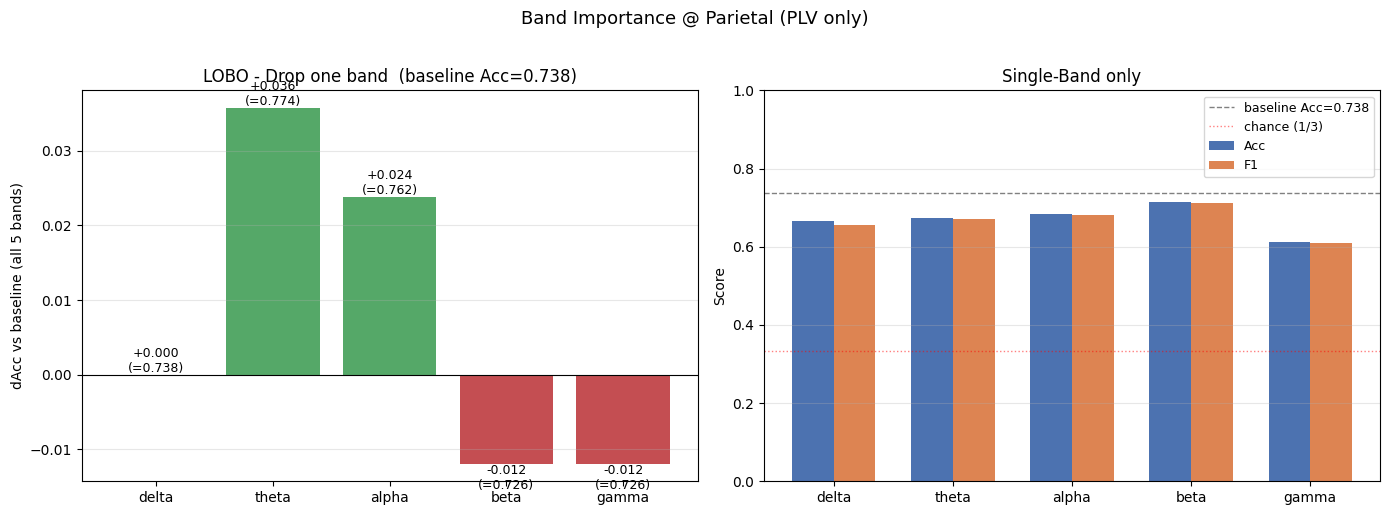

In [29]:
# ── 視覺化 1: LOBO + Single-Band Bar Chart ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
x = np.arange(len(BAND_NAMES))

# LOBO
ax = axes[0]
lobo_acc = [lobo_results[b]['acc'] for b in BAND_NAMES]
delta_acc = [a - baseline['acc'] for a in lobo_acc]
colors = ['#C44E52' if d < 0 else '#55A868' for d in delta_acc]
bars = ax.bar(x, delta_acc, color=colors)
ax.axhline(0, color='black', lw=0.8)
ax.set_xticks(x); ax.set_xticklabels(BAND_NAMES)
ax.set_ylabel('dAcc vs baseline (all 5 bands)')
ax.set_title(f'LOBO - Drop one band  (baseline Acc={baseline["acc"]:.3f})')
for b, d, a in zip(bars, delta_acc, lobo_acc):
    ax.text(b.get_x() + b.get_width()/2, d, f'{d:+.3f}\n(={a:.3f})',
            ha='center', va='bottom' if d >= 0 else 'top', fontsize=9)
ax.grid(axis='y', alpha=0.3)

# Single-Band
ax = axes[1]
single_acc = [single_results[b]['acc'] for b in BAND_NAMES]
single_f1  = [single_results[b]['f1']  for b in BAND_NAMES]
w = 0.35
ax.bar(x - w/2, single_acc, w, label='Acc', color='#4C72B0')
ax.bar(x + w/2, single_f1,  w, label='F1',  color='#DD8452')
ax.axhline(baseline['acc'], color='gray', ls='--', lw=1,
           label=f'baseline Acc={baseline["acc"]:.3f}')
ax.axhline(1/3, color='red', ls=':', lw=1, alpha=0.5, label='chance (1/3)')
ax.set_xticks(x); ax.set_xticklabels(BAND_NAMES)
ax.set_ylabel('Score'); ax.set_ylim(0, 1)
ax.set_title('Single-Band only')
ax.legend(fontsize=9); ax.grid(axis='y', alpha=0.3)

plt.suptitle(f'Band Importance @ {TARGET_REGION} (PLV only)', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(r'D:\Tseng\game_eeg\SVM_PLV\svm_plv_band_importance.png',
            dpi=150, bbox_inches='tight')
plt.show()

C:\Users\user\AppData\Local\Temp\ipykernel_18612\3173523795.py:39: UserWarning: Glyph 20986 (\N{CJK UNIFIED IDEOGRAPH-51FA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_18612\3173523795.py:39: UserWarning: Glyph 29694 (\N{CJK UNIFIED IDEOGRAPH-73FE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_18612\3173523795.py:39: UserWarning: Glyph 38971 (\N{CJK UNIFIED IDEOGRAPH-983B}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_18612\3173523795.py:39: UserWarning: Glyph 29575 (\N{CJK UNIFIED IDEOGRAPH-7387}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_18612\3173523795.py:39: UserWarning: Glyph 23376 (\N{CJK UNIFIED IDEOGRAPH-5B50}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_18612\3173523795.py:39: UserWarning: Glyph 38598 (\N{CJK 

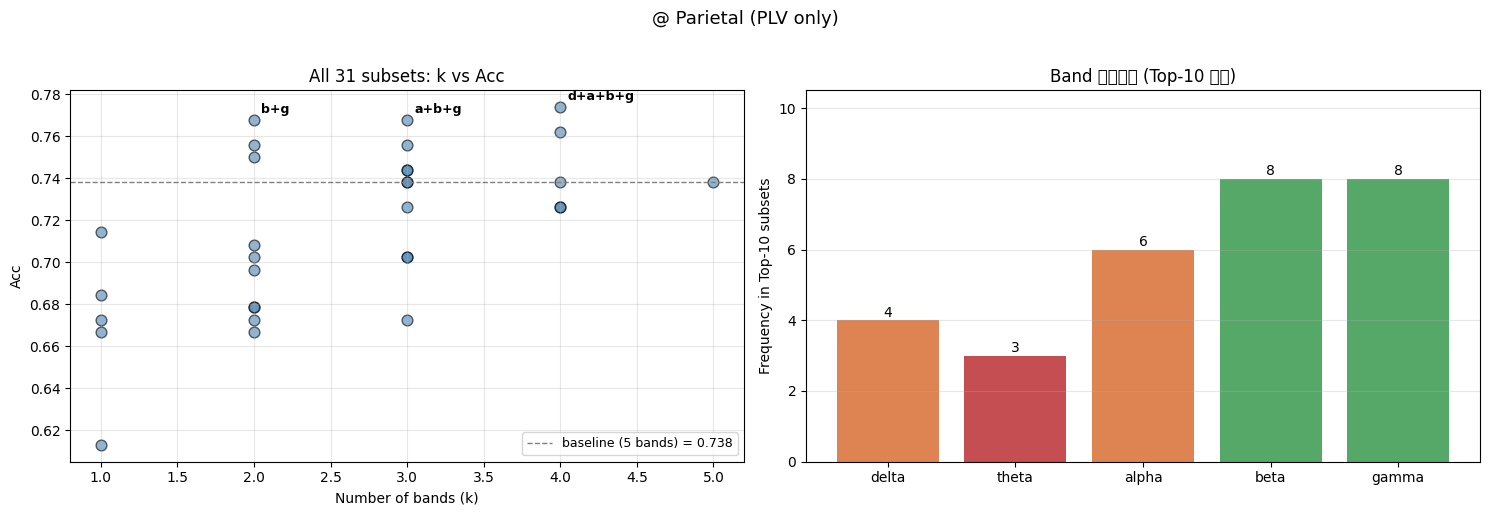

In [30]:
# ── 視覺化 2: 所有 31 子集 (k vs Acc) + band 出現頻率 ──
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Scatter: k vs Acc
ax = axes[0]
ks = [r['k'] for r in subset_results]
accs = [r['acc'] for r in subset_results]
ax.scatter(ks, accs, c='steelblue', s=60, alpha=0.6, edgecolors='black')
for r in subset_results_sorted[:3]:
    ax.annotate('+'.join(b[0] for b in r['names']),
                (r['k'], r['acc']),
                textcoords='offset points', xytext=(5, 5),
                fontsize=9, weight='bold')
ax.axhline(baseline['acc'], color='gray', ls='--', lw=1,
           label=f'baseline (5 bands) = {baseline["acc"]:.3f}')
ax.set_xlabel('Number of bands (k)'); ax.set_ylabel('Acc')
ax.set_title('All 31 subsets: k vs Acc')
ax.legend(fontsize=9); ax.grid(alpha=0.3)

# Band 出現頻率 in top-10 subsets
ax = axes[1]
top10 = subset_results_sorted[:10]
band_count = {b: 0 for b in BAND_NAMES}
for r in top10:
    for name in r['names']:
        band_count[name] += 1
counts = [band_count[b] for b in BAND_NAMES]
colors2 = ['#55A868' if c >= 7 else '#DD8452' if c >= 4 else '#C44E52' for c in counts]
ax.bar(range(len(BAND_NAMES)), counts, color=colors2)
ax.set_xticks(range(len(BAND_NAMES))); ax.set_xticklabels(BAND_NAMES)
ax.set_ylabel('Frequency in Top-10 subsets')
ax.set_title('Band 出現頻率 (Top-10 子集)')
for i, c in enumerate(counts):
    ax.text(i, c + 0.1, str(c), ha='center', fontsize=10)
ax.set_ylim(0, 10.5)
ax.grid(axis='y', alpha=0.3)

plt.suptitle(f'@ {TARGET_REGION} (PLV only)', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(r'D:\Tseng\game_eeg\SVM_PLV\svm_plv_subsets.png',
            dpi=150, bbox_inches='tight')
plt.show()